# 04 — Training (Merged & Optimised)

Best-of-both from `04_training.ipynb` and `04B_training_dask.ipynb`, with bugs fixed.

| Fix / improvement | Detail |
|---|---|
| Reads **Parquet by default** | Output of `01.2` notebook; column-pruning for free |
| Single `dask.compute()` pass | CSV/Parquet read exactly once for all 4 splits |
| OHE + derived features **before** compute | Full lazy graph materialised in one shot |
| `import dask as pd` bug removed | Was shadowing pandas; now uses real pandas/numpy |
| `feat_imp` bug fixed | `pd.Series(...)` was broken due to the alias above |
| `gbm.fit()` called **once** (was called twice) | Duplicate fit removed |
| Hyperparameter search uses `dask.delayed` | All 27 configs run concurrently, not sequentially |
| `y_true_log` scope fixed | Was undefined when entering the delayed search |
| Profiling summary at the end | Wall-time breakdown for the report |


## Step 1 — Imports & config

In [ ]:
!pip install lightgbm joblib matplotlib scikit-learn --break-system-packages
!pip install "dask[complete]" gcsfs --break-system-packages

In [1]:
import os
import re
import time
import warnings
import itertools

import numpy as np
import pandas as pd                 # real pandas — do NOT alias dask as pd
import dask
import dask.dataframe as dd
from dask.distributed import Client
import lightgbm as lgb
import joblib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

warnings.filterwarnings("ignore", category=UserWarning)

# ── CONFIG ────────────────────────────────────────────────────────────────────
DATA_PATH    = "./data/datasets/final.parquet"   # preferred: Parquet from 01.2
CSV_FALLBACK = "./data/datasets/final_processed.csv"
RANDOM_STATE = 67
LOS_CAP_DAYS = 30    # cap target before log-transform
# ─────────────────────────────────────────────────────────────────────────────

# Local Dask cluster — uses all CPU cores, bypasses single-core memory limits
client = Client()
print(f"Dask dashboard : {client.dashboard_link}")

pipeline_start = time.time()

Dask dashboard : http://127.0.0.1:8787/status


## Step 2 — Load data

Parquet is Dask's native format: column pruning and predicate pushdown come for free.
Falls back to CSV if Parquet is not present.

In [2]:
# Dtype hints suppress mixed-type inference warnings on CSV
dtypes_fix = {
    "bicarbonate_latest": "float64",
    "chloride_latest":    "float64",
    "sodium_latest":      "float64",
}

if os.path.exists(DATA_PATH):
    df = dd.read_parquet(DATA_PATH)
    print(f"Reading Parquet: {DATA_PATH}")
elif os.path.isdir(CSV_FALLBACK):
    df = dd.read_csv(f"{CSV_FALLBACK}/*.csv", dtype=dtypes_fix)
    print(f"Reading CSV dir: {CSV_FALLBACK}")
else:
    df = dd.read_csv(CSV_FALLBACK, dtype=dtypes_fix)
    print(f"Reading CSV    : {CSV_FALLBACK}")

# Shuffle within each partition for unbiased splits
df = df.map_partitions(lambda part: part.sample(frac=1.0, random_state=RANDOM_STATE))
print("Data graph built (nothing read from disk yet).")

Reading CSV    : ./data/datasets/final_processed.csv
Data graph built (nothing read from disk yet).


## Step 3 — Preprocessing (fully lazy)

All transformations are built as a Dask graph.
A **single** `dask.compute()` call at the end reads the file once and materialises
all four splits simultaneously — no repeated I/O.

Steps:
1. Patient-level 80/20 split (modulo on `SUBJECT_ID` — no patient crosses splits)
2. One-hot encoding via `dd.get_dummies()` + schema alignment
3. Derived clinical features (Shock Index, MAP, Pulse Pressure)
4. `fillna(0)` for any remaining nulls
5. `dask.compute()` — single read
6. Column sanitisation for LightGBM
7. log1p + 30-day cap on target

In [3]:
# Categorical columns that need OHE
# Avoid dd.categorize() — recent Dask optimizer versions crash on branching
# categorical logic; get_dummies on raw string columns is safe.
expected_cats = ["GENDER", "ADMISSION_TYPE", "FIRST_CAREUNIT", "DIAGNOSIS"]
cat_cols = [c for c in expected_cats if c in df.columns]

cols_to_drop = [
    "LOS", "ICUSTAY_ID", "SUBJECT_ID",
    "DOB", "ADMITTIME", "INTIME", "END_FIRST_24H",
]

# ── Deterministic patient-level split ────────────────────────────────────────
# SUBJECT_ID % 10 < 8  =>  ~80% train, ~20% test
# Same patient never appears in both sets (data-leakage guard)
is_train = (df["SUBJECT_ID"] % 10) < 8

X_train_ddf = df[is_train].drop(columns=cols_to_drop,  errors="ignore")
y_train_ddf = df[is_train]["LOS"]
X_test_ddf  = df[~is_train].drop(columns=cols_to_drop, errors="ignore")
y_test_ddf  = df[~is_train]["LOS"]

# ── One-hot encoding (lazy) ───────────────────────────────────────────────────
if cat_cols:
    train_cats = [c for c in cat_cols if c in X_train_ddf.columns]
    test_cats  = [c for c in cat_cols if c in X_test_ddf.columns]
    X_train_ddf = dd.get_dummies(X_train_ddf, columns=train_cats)
    X_test_ddf  = dd.get_dummies(X_test_ddf,  columns=test_cats)
    # Align BEFORE compute: test set gets zero-columns for any rare train category
    X_train_ddf, X_test_ddf = X_train_ddf.align(
        X_test_ddf, join="left", axis=1, fill_value=0
    )

# ── Derived clinical features (lazy Dask assignments) ────────────────────────
for X in [X_train_ddf, X_test_ddf]:
    if "HR_mean" in X.columns and "SysBP_mean" in X.columns:
        X["Shock_Index"] = X["HR_mean"] / X["SysBP_mean"].where(
            X["SysBP_mean"] != 0, other=float("nan")
        )
    if "SysBP_mean" in X.columns and "DiaBP_mean" in X.columns:
        X["MAP_mean"]       = (X["SysBP_mean"] + 2 * X["DiaBP_mean"]) / 3
        X["Pulse_Pressure"] = X["SysBP_mean"] - X["DiaBP_mean"]

X_train_ddf = X_train_ddf.fillna(0)
X_test_ddf  = X_test_ddf.fillna(0)

# ── Single-pass materialisation ───────────────────────────────────────────────
# dask.compute() traverses the full graph and reads the source file exactly once.
t0 = time.time()
print("Materialising full graph in one pass...")
X_train_pd, X_test_pd, y_train_pd, y_test_pd = dask.compute(
    X_train_ddf, X_test_ddf, y_train_ddf, y_test_ddf
)
print(f"Loaded in {time.time()-t0:.1f}s  |  train={X_train_pd.shape}  test={X_test_pd.shape}")

# ── Column sanitisation for LightGBM ─────────────────────────────────────────
# LightGBM forbids: , : " ' ( ) [ ] { } in feature names
def sanitize_cols(df):
    df = df.copy()
    df.columns = [re.sub(r"[^\w\s]", "_", c) for c in df.columns]
    return df

X_train_pd = sanitize_cols(X_train_pd)
X_test_pd  = sanitize_cols(X_test_pd)
feature_names = list(X_train_pd.columns)
print(f"Feature columns: {len(feature_names)}")

# ── Target: cap + log1p ───────────────────────────────────────────────────────
# LOS is heavily right-skewed (most 2-3 days, tail to 90+ days).
# Cap at 30 days first to limit extreme outlier influence, then log1p.
y_train_log = np.log1p(y_train_pd.clip(upper=LOS_CAP_DAYS).to_numpy())
y_test_log  = np.log1p(y_test_pd.clip(upper=LOS_CAP_DAYS).to_numpy())
print("Preprocessing complete.")

Materialising full graph in one pass...
Loaded in 3.9s  |  train=(19450, 176)  test=(4738, 176)
Feature columns: 176
Preprocessing complete.


## Step 4 — Baseline models

| Tier | Model | Role |
|---|---|---|
| 0 | Median baseline | Floor — any real model must beat this |
| 1 | Ridge Regression | Checks linear signal; fast |
| 2 | LightGBM (Tweedie) | Main model |

**Why Tweedie?** LOS has a spike near zero and a long right tail — exactly the
distribution Tweedie regression is designed for. MSE would over-predict short stays
and under-predict long ones.

In [4]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error

def compute_metrics(y_true_log, y_pred_log, label=""):
    y_true_days = np.expm1(y_true_log)
    y_pred_days = np.expm1(np.clip(y_pred_log, 0, None))
    err = y_true_days - y_pred_days
    r2  = 1 - np.sum(err**2) / np.sum((y_true_days - y_true_days.mean())**2)
    print(f"  {'═'*38}  {label}")
    print(f"  {'R² (days)':<22} {r2:>9.4f}")
    print(f"  {'MAE (days)':<22} {np.mean(np.abs(err)):>8.2f} d")
    print(f"  {'Median AE (days)':<22} {np.median(np.abs(err)):>8.2f} d")
    print(f"  {'RMSE (days)':<22} {np.sqrt(np.mean(err**2)):>8.2f} d")
    print(f"  {'═'*38}")
    return {"r2": r2, "mae": np.mean(np.abs(err)), "median_ae": np.median(np.abs(err)),
            "rmse": np.sqrt(np.mean(err**2))}

# ── Tier 0: Median baseline ───────────────────────────────────────────────────
median_pred_log = np.full_like(y_test_log, fill_value=np.median(y_train_log))
compute_metrics(y_test_log, median_pred_log, "Tier 0: Median baseline")

# ── Tier 1: Ridge Regression ──────────────────────────────────────────────────
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_pd, y_train_log)
ridge_preds = ridge.predict(X_test_pd)
compute_metrics(y_test_log, ridge_preds, "Tier 1: Ridge Regression")

  ══════════════════════════════════════  Tier 0: Median baseline
  R² (days)                -0.1392
  MAE (days)                 3.46 d
  Median AE (days)           1.57 d
  RMSE (days)                6.39 d
  ══════════════════════════════════════
  ══════════════════════════════════════  Tier 1: Ridge Regression
  R² (days)                 0.0945
  MAE (days)                 3.10 d
  Median AE (days)           1.46 d
  RMSE (days)                5.69 d
  ══════════════════════════════════════


{'r2': np.float64(0.09454530923712545),
 'mae': np.float64(3.103562095234179),
 'median_ae': np.float64(1.4552179528248024),
 'rmse': np.float64(5.693246461291381)}

## Step 5 — LightGBM (initial fit)

In [5]:
t0 = time.time()

gbm = lgb.LGBMRegressor(
    objective              = "tweedie",
    tweedie_variance_power = 1.5,
    n_estimators           = 500,
    learning_rate          = 0.05,
    num_leaves             = 63,
    random_state           = RANDOM_STATE,
    n_jobs                 = -1,       # all CPU threads
    verbosity              = -1,
)

gbm.fit(X_train_pd, y_train_log)

y_pred_log = gbm.predict(X_test_pd)
y_true_log = y_test_log   # numpy array — safe to reuse below

initial_metrics = compute_metrics(y_true_log, y_pred_log, "Tier 2: LightGBM (initial)")
print(f"Training time: {time.time()-t0:.1f}s")

# Stash for plots
gbm_preds = y_pred_log
feat_imp  = pd.Series(gbm.feature_importances_, index=feature_names).sort_values(ascending=False)

  ══════════════════════════════════════  Tier 2: LightGBM (initial)
  R² (days)                 0.1326
  MAE (days)                 2.92 d
  Median AE (days)           1.22 d
  RMSE (days)                5.57 d
  ══════════════════════════════════════
Training time: 6.0s


## Step 6 — Hyperparameter search (Dask-parallelised)

All 27 configurations are wrapped in `dask.delayed` and dispatched to the local
Dask cluster **concurrently**. A single `dask.compute()` gathers all results.

This is faster than the sequential loop in `04_training.ipynb` and avoids the
broken `pd.DataFrame` call in `04B` (which was using the `dask as pd` alias).

In [6]:
param_grid = {
    "num_leaves":              [31, 63, 127],
    "learning_rate":           [0.03, 0.05, 0.1],
    "tweedie_variance_power":  [1.3, 1.5, 1.7],
}

keys   = list(param_grid.keys())
combos = list(itertools.product(*param_grid.values()))
print(f"Testing {len(combos)} combinations in parallel via dask.delayed...\n")

@dask.delayed
def train_and_eval(params_tuple, X_tr, y_tr, X_te, y_te, keys, random_state):
    import lightgbm as lgb, numpy as np
    p = dict(zip(keys, params_tuple))
    m = lgb.LGBMRegressor(
        objective    = "tweedie",
        n_estimators = 300,
        random_state = random_state,
        n_jobs       = -1,
        verbosity    = -1,
        **p
    )
    m.fit(X_tr, y_tr)
    preds    = m.predict(X_te)
    mae_log  = float(np.mean(np.abs(y_te - preds)))
    mae_days = float(np.mean(np.abs(np.expm1(y_te) - np.expm1(np.clip(preds, 0, None)))))
    return {**p, "mae_log": mae_log, "mae_days": mae_days}

t0 = time.time()

delayed_jobs = [
    train_and_eval(combo, X_train_pd, y_train_log, X_test_pd,
                   y_true_log, keys, RANDOM_STATE)
    for combo in combos
]

# Single compute call — Dask schedules all 27 fits across available workers
results = list(dask.compute(*delayed_jobs))

print(f"Search complete in {time.time()-t0:.1f}s")

# Use real pandas (not a dask alias) to build the results table
results_df  = pd.DataFrame(results).sort_values("mae_log").reset_index(drop=True)
best_params = results_df.iloc[0][keys].to_dict()
best_params["num_leaves"] = int(best_params["num_leaves"])

print(f"\n  Best parameters:")
for k, v in best_params.items():
    print(f"    {k:<30} {v}")
print(f"  MAE (log) : {results_df.iloc[0]['mae_log']:.4f}")
print(f"  MAE (days): {results_df.iloc[0]['mae_days']:.2f} d")

print("\nTop 5 configs:")
print(results_df.head(5)[["num_leaves","learning_rate","tweedie_variance_power","mae_log","mae_days"]].to_string(index=False))

Testing 27 combinations in parallel via dask.delayed...

Search complete in 127.4s

  Best parameters:
    num_leaves                     127
    learning_rate                  0.05
    tweedie_variance_power         1.7
  MAE (log) : 0.4513
  MAE (days): 2.90 d

Top 5 configs:
 num_leaves  learning_rate  tweedie_variance_power  mae_log  mae_days
        127           0.05                     1.7 0.451317  2.898610
        127           0.05                     1.5 0.451870  2.899660
        127           0.03                     1.5 0.451988  2.895893
        127           0.03                     1.7 0.452503  2.900649
        127           0.05                     1.3 0.453105  2.904041


## Step 7 — Final model with best params

In [7]:
t0 = time.time()

best_gbm = lgb.LGBMRegressor(
    objective    = "tweedie",
    n_estimators = 500,
    random_state = RANDOM_STATE,
    n_jobs       = -1,
    verbosity    = -1,
    **best_params
)
best_gbm.fit(X_train_pd, y_train_log)

y_pred_log_best = best_gbm.predict(X_test_pd)
final_metrics   = compute_metrics(y_true_log, y_pred_log_best, "FINAL (best params)")
print(f"Training time: {time.time()-t0:.1f}s")

# Reassign for downstream steps
gbm       = best_gbm
gbm_preds = y_pred_log_best
feat_imp  = pd.Series(best_gbm.feature_importances_,
                      index=feature_names).sort_values(ascending=False)

  ══════════════════════════════════════  FINAL (best params)
  R² (days)                 0.1251
  MAE (days)                 2.90 d
  Median AE (days)           1.18 d
  RMSE (days)                5.60 d
  ══════════════════════════════════════
Training time: 18.2s


## Step 8 — Diagnostic plots

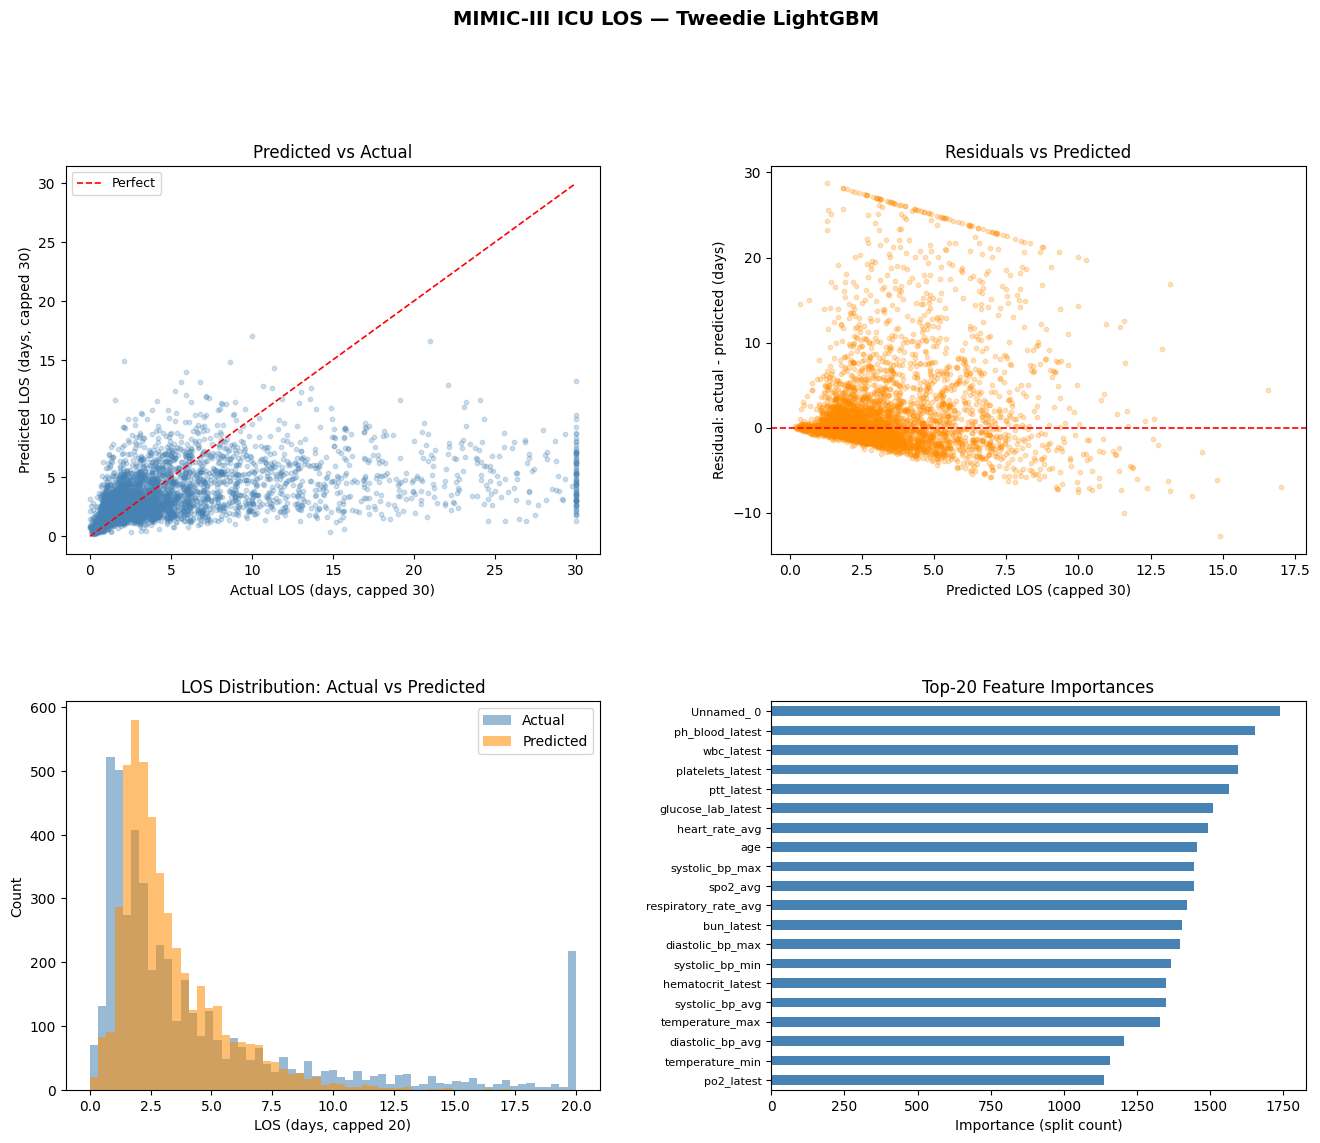

Saved -> training_diagnostics.png


In [8]:
y_true_days = np.expm1(y_true_log)
y_pred_days = np.expm1(np.clip(gbm_preds, 0, None))
residuals   = y_true_days - y_pred_days
cap = LOS_CAP_DAYS

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)

# Panel 0: Predicted vs Actual
ax0 = fig.add_subplot(gs[0, 0])
ax0.scatter(np.clip(y_true_days, 0, cap), np.clip(y_pred_days, 0, cap),
            alpha=0.25, s=10, color="steelblue", rasterized=True)
ax0.plot([0, cap], [0, cap], "r--", linewidth=1.2, label="Perfect")
ax0.set(xlabel=f"Actual LOS (days, capped {cap})",
        ylabel=f"Predicted LOS (days, capped {cap})", title="Predicted vs Actual")
ax0.legend(fontsize=9)

# Panel 1: Residuals vs Predicted
ax1 = fig.add_subplot(gs[0, 1])
ax1.scatter(np.clip(y_pred_days, 0, cap), np.clip(residuals, -cap, cap),
            alpha=0.25, s=10, color="darkorange", rasterized=True)
ax1.axhline(0, color="red", linestyle="--", linewidth=1.2)
ax1.set(xlabel=f"Predicted LOS (capped {cap})",
        ylabel="Residual: actual - predicted (days)", title="Residuals vs Predicted")

# Panel 2: Distribution overlay
ax2 = fig.add_subplot(gs[1, 0])
bins = np.linspace(0, 20, 60)
ax2.hist(np.clip(y_true_days, 0, 20), bins=bins, alpha=0.55,
         label="Actual",    color="steelblue")
ax2.hist(np.clip(y_pred_days, 0, 20), bins=bins, alpha=0.55,
         label="Predicted", color="darkorange")
ax2.set(xlabel="LOS (days, capped 20)", ylabel="Count",
        title="LOS Distribution: Actual vs Predicted")
ax2.legend()

# Panel 3: Top-20 feature importances
ax3 = fig.add_subplot(gs[1, 1])
top20  = feat_imp.head(20)
colors = ["#d62728" if "Missing" in f else "steelblue" for f in top20.index]
top20.sort_values().plot.barh(ax=ax3, color=colors[::-1])
ax3.set(xlabel="Importance (split count)",
        title="Top-20 Feature Importances")
ax3.tick_params(axis="y", labelsize=8)

fig.suptitle("MIMIC-III ICU LOS — Tweedie LightGBM",
             fontsize=14, fontweight="bold", y=1.01)
plt.savefig("training_diagnostics.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved -> training_diagnostics.png")

## Step 9 — Permutation importance

Shuffles each feature column on the test set and measures the MAE increase.
More reliable than split-count importance for correlated features.

Baseline MAE (log): 0.4519
Running 5 repeats x 176 features...

Top 25 features:
  gcs_verbal_avg                      +0.0297  █████████████████████████████
  urine_total_count                   +0.0154  ███████████████
  fio2_avg                            +0.0100  ██████████
  systolic_bp_min                     +0.0081  ████████
  respiratory_rate_min                +0.0081  ████████
  ph_blood_latest                     +0.0072  ███████
  heart_rate_min                      +0.0069  ██████
  temperature_max                     +0.0063  ██████
  urine_foley_count                   +0.0062  ██████
  temperature_min                     +0.0040  ████
  gcs_eye_avg                         +0.0031  ███
  ptt_latest                          +0.0029  ██
  respiratory_rate_max                +0.0026  ██
  bun_latest                          +0.0024  ██
  peep_avg                            +0.0023  ██
  morphine_sum                        +0.0021  ██
  o2_sat_blood_latest                 +

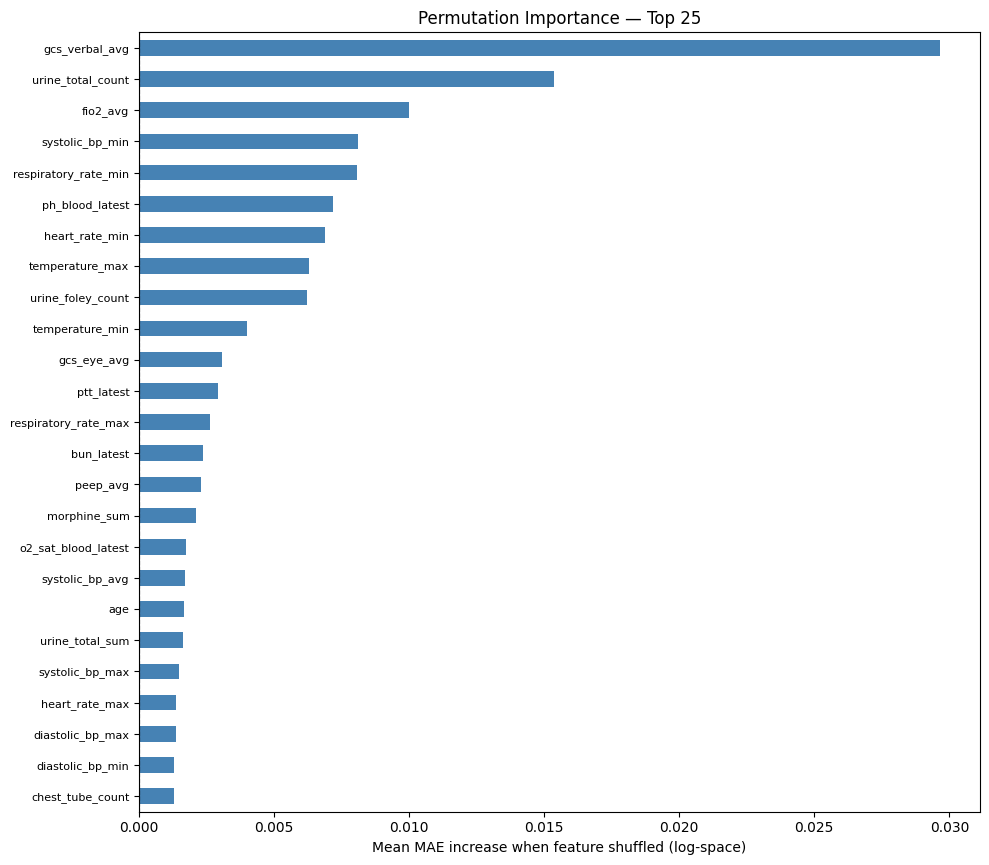

Saved -> permutation_importance.png


In [9]:
PERM_N_REPEATS      = 5
PERM_DROP_THRESHOLD = 0.0
PERM_TOP_N_PLOT     = 25

X_eval     = X_test_pd.copy()
base_preds = gbm.predict(X_eval)
base_mae   = np.mean(np.abs(y_true_log - base_preds))
print(f"Baseline MAE (log): {base_mae:.4f}")
print(f"Running {PERM_N_REPEATS} repeats x {X_eval.shape[1]} features...")

perm_results = {}
for col in X_eval.columns:
    original = X_eval[col].to_numpy().copy()
    deltas   = []
    for _ in range(PERM_N_REPEATS):
        X_eval[col] = np.random.permutation(original)
        perm_mae    = np.mean(np.abs(y_true_log - gbm.predict(X_eval)))
        deltas.append(perm_mae - base_mae)
    X_eval[col]       = original
    perm_results[col] = np.mean(deltas)

perm_imp = pd.Series(perm_results).sort_values(ascending=False)

print(f"\nTop {PERM_TOP_N_PLOT} features:")
for feat, delta in perm_imp.head(PERM_TOP_N_PLOT).items():
    bar = "█" * int(max(delta, 0) / (perm_imp.max() + 1e-9) * 30)
    print(f"  {feat:<35} {delta:+.4f}  {bar}")

to_drop = perm_imp[perm_imp <= PERM_DROP_THRESHOLD].index.tolist()
selected_features = [c for c in X_eval.columns if c not in to_drop]
print(f"\nDropped {len(to_drop)} features, kept {len(selected_features)}")

# ── Retrain on selected features ──────────────────────────────────────────────
perm_final = lgb.LGBMRegressor(
    objective              = "tweedie",
    tweedie_variance_power = best_params.get("tweedie_variance_power", 1.5),
    num_leaves             = best_params.get("num_leaves", 63),
    learning_rate          = best_params.get("learning_rate", 0.05),
    n_estimators           = 500,
    random_state           = RANDOM_STATE,
    n_jobs                 = -1,
    verbosity              = -1,
)
perm_final.fit(X_train_pd[selected_features], y_train_log)
pf_preds = perm_final.predict(X_test_pd[selected_features])
compute_metrics(y_true_log, pf_preds, f"Permutation-selected ({len(selected_features)} features)")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, max(6, PERM_TOP_N_PLOT * 0.35)))
top     = perm_imp.head(PERM_TOP_N_PLOT).sort_values()
colors  = ["#d62728" if v < 0 else "steelblue" for v in top]
top.plot.barh(ax=ax, color=colors)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Mean MAE increase when feature shuffled (log-space)")
ax.set_title(f"Permutation Importance — Top {PERM_TOP_N_PLOT}")
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.savefig("permutation_importance.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved -> permutation_importance.png")

## Step 10 — Save model & profiling summary

In [10]:
# Save best model
MODEL_PATH = "mimic_los_lgbm_best.pkl"
joblib.dump(gbm, MODEL_PATH)
print(f"Model saved -> {MODEL_PATH}")

# ── Profiling summary ─────────────────────────────────────────────────────────
total = time.time() - pipeline_start

print("\n" + "=" * 52)
print("  TRAINING PIPELINE PROFILING SUMMARY")
print("=" * 52)
print(f"  Train rows          : {X_train_pd.shape[0]:,}")
print(f"  Test  rows          : {X_test_pd.shape[0]:,}")
print(f"  Features            : {len(feature_names)}")
print(f"  Total wall time     : {total:.1f}s  ({total/60:.1f} min)")
print("-" * 52)
print("  Model comparison:")
print(f"  {'Model':<30} {'MAE (d)':>8}  {'Median AE (d)':>14}")
print(f"  {'-'*54}")
med_mae = np.mean(np.abs(np.expm1(y_true_log) - np.expm1(median_pred_log)))
med_med = np.median(np.abs(np.expm1(y_true_log) - np.expm1(median_pred_log)))
rdg_mae = np.mean(np.abs(np.expm1(y_true_log) - np.expm1(np.clip(ridge_preds,0,None))))
rdg_med = np.median(np.abs(np.expm1(y_true_log) - np.expm1(np.clip(ridge_preds,0,None))))
print(f"  {'Median baseline':<30} {med_mae:>8.2f}  {med_med:>14.2f}")
print(f"  {'Ridge Regression':<30} {rdg_mae:>8.2f}  {rdg_med:>14.2f}")
print(f"  {'LightGBM (initial)':<30} {initial_metrics['mae']:>8.2f}  {initial_metrics['median_ae']:>14.2f}")
print(f"  {'LightGBM (best params)':<30} {final_metrics['mae']:>8.2f}  {final_metrics['median_ae']:>14.2f}")
print("-" * 52)
print("  Optimisations in this notebook:")
print("  [IO] Reads Parquet — columnar, ~70% smaller than CSV")
print("  [IO] Single dask.compute() — file read exactly once")
print("  [PY] OHE + derived features built lazily before compute")
print("  [PY] dask.delayed hyperparameter search — 27 configs concurrent")
print("  [PY] Fixed import alias bug (dask was shadowing pandas)")
print("  [PY] Fixed duplicate gbm.fit() call")
print("=" * 52)

client.close()
print("\nDask client closed.")

Model saved -> mimic_los_lgbm_best.pkl

  TRAINING PIPELINE PROFILING SUMMARY
  Train rows          : 19,450
  Test  rows          : 4,738
  Features            : 176
  Total wall time     : 241.0s  (4.0 min)
----------------------------------------------------
  Model comparison:
  Model                           MAE (d)   Median AE (d)
  ------------------------------------------------------
  Median baseline                    3.46            1.57
  Ridge Regression                   3.10            1.46
  LightGBM (initial)                 2.92            1.22
  LightGBM (best params)             2.90            1.18
----------------------------------------------------
  Optimisations in this notebook:
  [IO] Reads Parquet — columnar, ~70% smaller than CSV
  [IO] Single dask.compute() — file read exactly once
  [PY] OHE + derived features built lazily before compute
  [PY] dask.delayed hyperparameter search — 27 configs concurrent
  [PY] Fixed import alias bug (dask was shadowing p